In [225]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
# plt.style.available

### Colored Scatterplots

In [226]:
iris = pd.read_csv('../data/iris.csv')
iris.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
22,23,4.6,3.6,1.0,0.2,Iris-setosa
42,43,4.4,3.2,1.3,0.2,Iris-setosa
18,19,5.7,3.8,1.7,0.3,Iris-setosa
130,131,7.4,2.8,6.1,1.9,Iris-virginica
137,138,6.4,3.1,5.5,1.8,Iris-virginica


In [227]:
# iris['Species'] = iris['Species'].replace({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2})
# iris.sample(5)

# using apply methods
def assign_specices(row):
    if row['Species'] == "Iris-setosa":
        return 0
    elif row['Species'] == "Iris-versicolor":
        return 1
    else:
        return 2
    
    
iris['SpeciesCode'] = iris.apply(assign_specices,axis=1)
iris.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,SpeciesCode
98,99,5.1,2.5,3.0,1.1,Iris-versicolor,1
4,5,5.0,3.6,1.4,0.2,Iris-setosa,0
146,147,6.3,2.5,5.0,1.9,Iris-virginica,2
41,42,4.5,2.3,1.3,0.3,Iris-setosa,0
72,73,6.3,2.5,4.9,1.5,Iris-versicolor,1


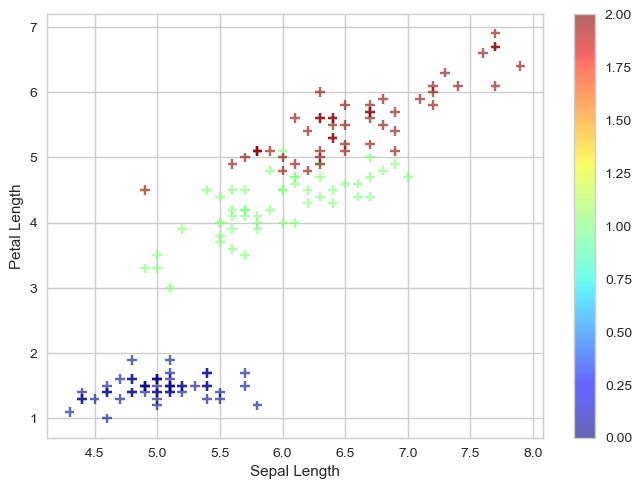

In [228]:
plt.scatter(iris['SepalLengthCm'],iris['PetalLengthCm'],c=iris['SpeciesCode'],cmap='jet',alpha=0.6 , marker='+') # cmap : colour combination, alpha : transparency
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.colorbar()

In [229]:
# cmap and alpha

### Plot size

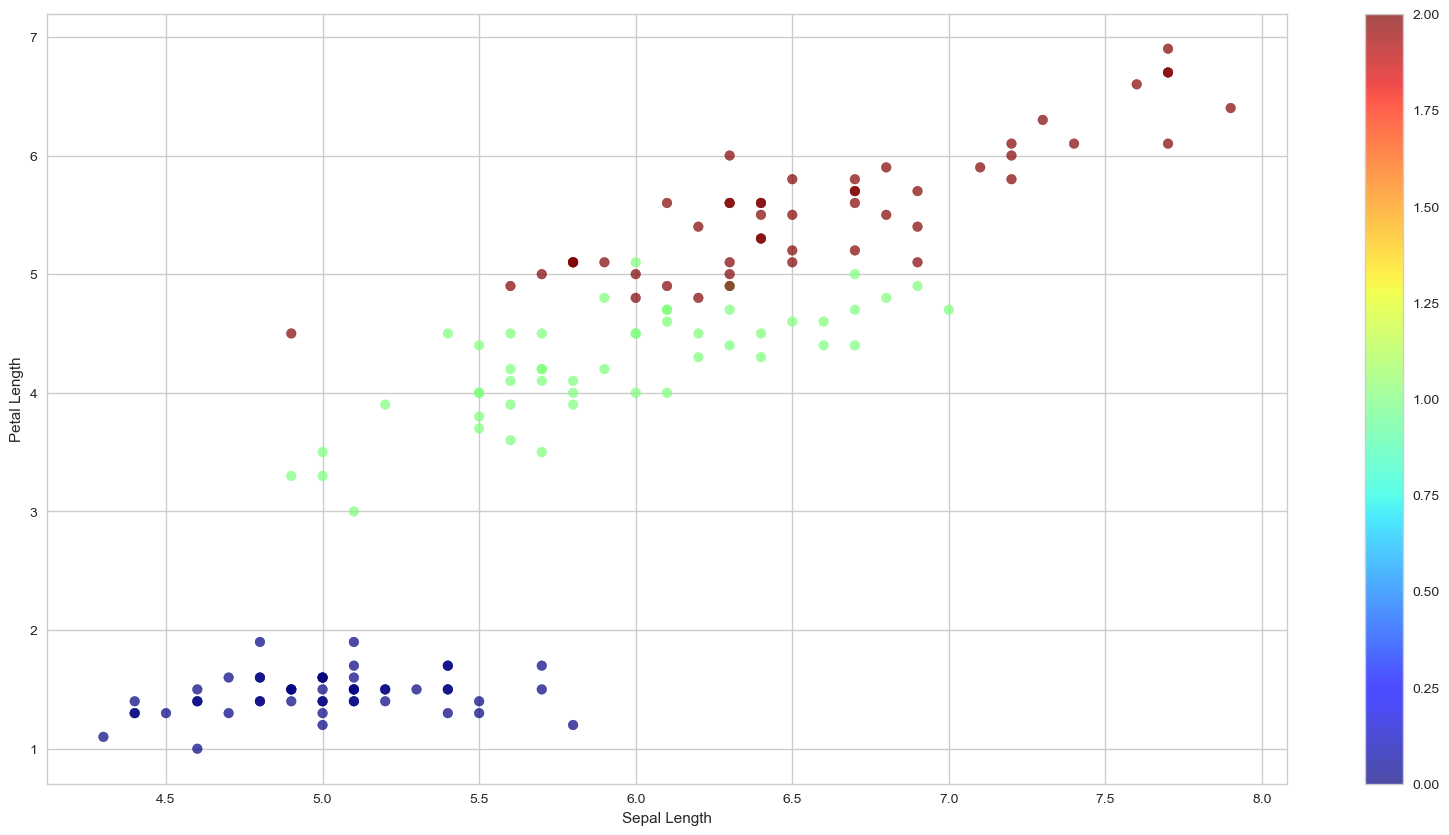

In [230]:
plt.figure(figsize=(20,10))

plt.scatter(iris['SepalLengthCm'],iris['PetalLengthCm'],c=iris['SpeciesCode'],cmap='jet',alpha=0.7)
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.colorbar()

### Annotations

In [231]:
batters = pd.read_csv('../data/batter.csv')

In [232]:
batters.shape

(605, 4)

In [233]:
batters.head(5)

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312


In [234]:
sample_df = batters.head(100).sample(25,random_state=5)

In [235]:
sample_df

,batter,runs,avg,strike_rate
66,KH Pandya,1326,22.100000,132.203390
32,SE Marsh,2489,39.507937,130.109775
46,JP Duminy,2029,39.784314,120.773810
28,SA Yadav,2644,29.707865,134.009123
74,IK Pathan,1150,21.698113,116.751269
23,JC Buttler,2832,39.333333,144.859335
10,G Gambhir,4217,31.007353,119.665153
20,BB McCullum,2882,27.711538,126.848592
17,KA Pollard,3437,28.404959,140.457703
35,WP Saha,2427,25.281250,124.397745


- Anotations are used to add text to a plot. It can be used to highlight a specific point in the plot. using `plt.text(2,6,'point_name')` 

Text(4, 8, 'Point 4')

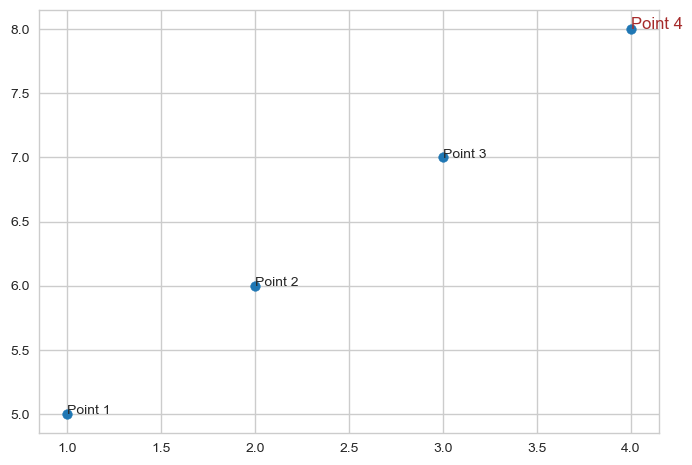

In [236]:
x = [1,2,3,4]
y = [5,6,7,8]

plt.scatter(x,y)
plt.text(1,5,'Point 1')
plt.text(2,6,'Point 2')
plt.text(3,7,'Point 3')
plt.text(4,8,'Point 4',fontdict={'size':12,'color':'brown'})

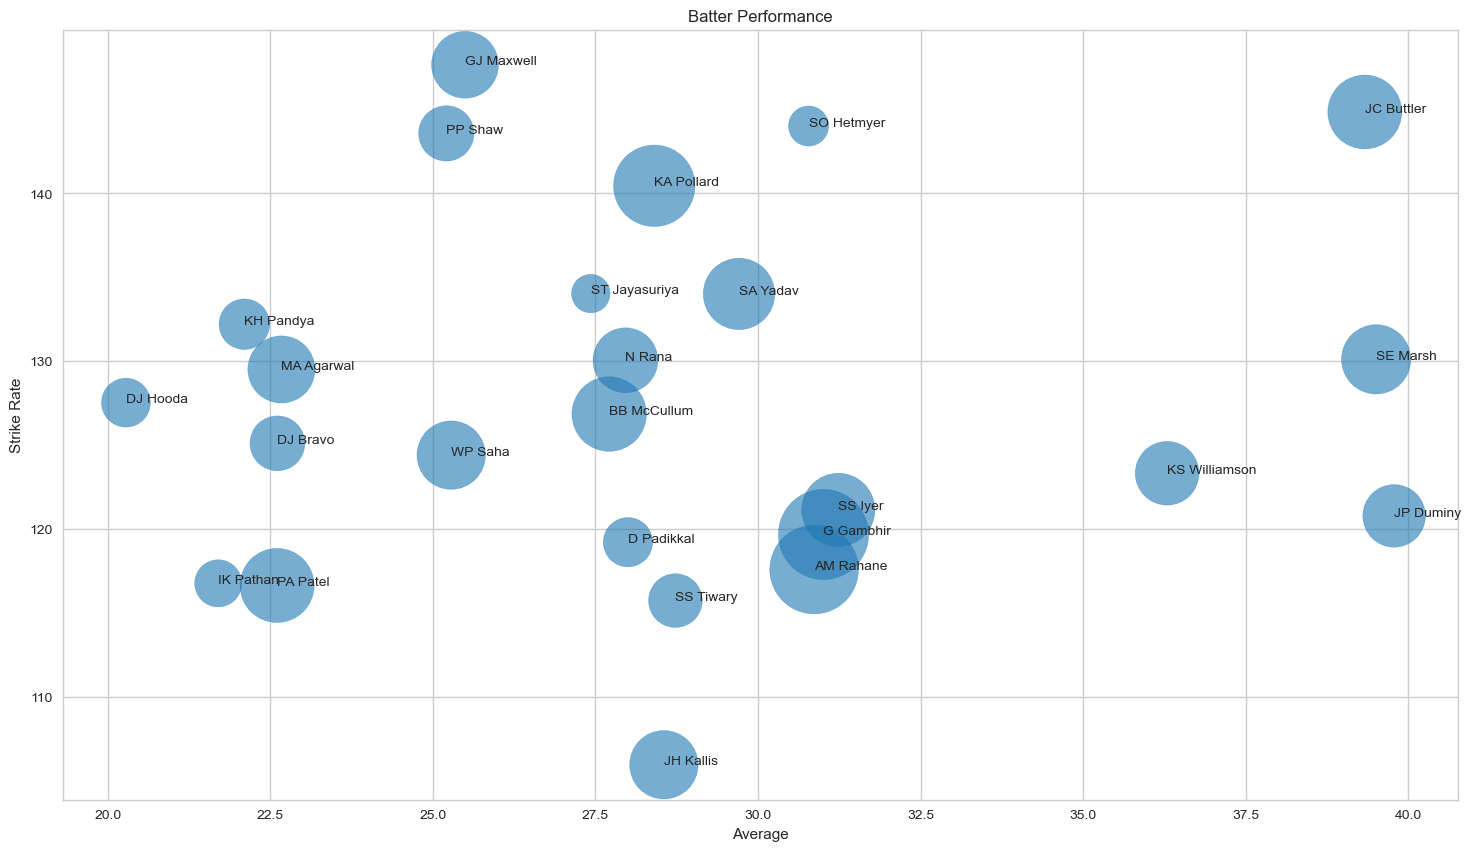

In [237]:
plt.figure(figsize=(18,10))
plt.scatter(sample_df['avg'],sample_df['strike_rate'],s=sample_df['runs'] , alpha=0.6 )
plt.xlabel('Average')
plt.ylabel('Strike Rate')
plt.title('Batter Performance')
for i in range(sample_df.shape[0]):
  plt.text(sample_df['avg'].values[i],sample_df['strike_rate'].values[i],sample_df['batter'].values[i])

### Horizontal and Vertical lines

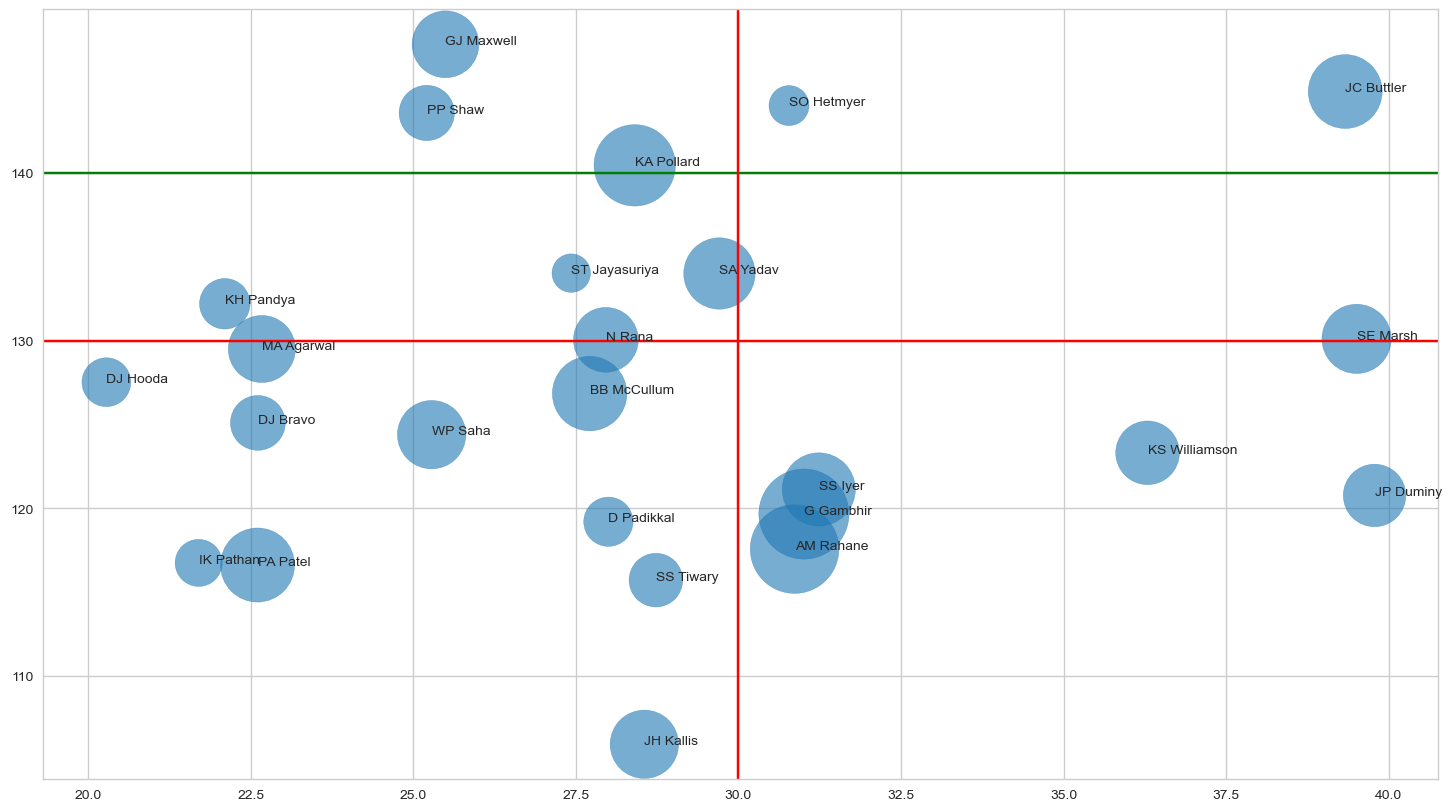

In [238]:
plt.figure(figsize=(18,10))
plt.scatter(sample_df['avg'],sample_df['strike_rate'],s=sample_df['runs'],alpha=0.6 )

plt.axhline(130,color='red')
plt.axhline(140,color='green')
plt.axvline(30,color='red')

for i in range(sample_df.shape[0]):
  plt.text(sample_df['avg'].values[i],sample_df['strike_rate'].values[i],sample_df['batter'].values[i])

### Subplots

#### when you call the .subplots() function, it returns a figure and an array of axes objects. You can use these axes objects to plot on different subplots.

creates two different objects:
 - fig → the Figure object — the whole canvas/window.
 - ax → the Axes object — the actual plotting area where you draw graphs.

```
 Figure (fig)
┌───────────────────────────────────────────────┐
│                                               │
│        Axes (ax)                              │
│       ┌───────────────────────────────┐       │
│       │                               │       │
│       │       Your plot               │       │
│       │                               │       │
│       └───────────────────────────────┘       │
│                                               │
└───────────────────────────────────────────────┘
```


#### 1. fig = Figure ::: The Figure is the top-level container.

`fig, ax = plt.subplots(figsize=(15, 6))` Here: fig represents the entire 15 × 6 inch figure.

You can use it for things like:

```
fig.suptitle("My Analysis")
fig.savefig("plot.png")
fig.tight_layout()
```

For example:

```
fig, ax = plt.subplots(figsize=(15, 6))
fig.suptitle("Sales Analysis")
```

The title belongs to the whole figure.


#### 2. ax = Axes   :::   ax is the actual plotting region.

You normally use ax for your data:

```
ax.plot(x, y)
ax.scatter(x, y)
ax.bar(categories, values)
ax.set_title("Sales")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
```

For example:

```
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot([1, 2, 3, 4], [10, 20, 15, 30])

ax.set_title("Sales")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")

plt.show()
```

The important distinction is:

```
fig
 │
 └── ax
      │
      ├── plot()
      ├── scatter()
      ├── bar()
      ├── set_title()
      ├── set_xlabel()
      └── set_ylabel()

```
A Figure can contain multiple Axes.

For example:

`fig, axes = plt.subplots(2, 2)`

creates:

```
             Figure
┌─────────────────────────────────┐
│                                 │
│   Axes 1       Axes 2           │
│  ┌───────┐    ┌───────┐         │
│  │       │    │       │         │
│  └───────┘    └───────┘         │
│                                 │
│   Axes 3       Axes 4           │
│  ┌───────┐    ┌───────┐         │
│  │       │    │       │         │
│  └───────┘    └───────┘         │
│                                 │
└─────────────────────────────────┘
```

So: `fig, axes = plt.subplots(2, 2)`  means:  `fig`  # one Figure   and   `axes`  # 2 × 2 array containing 4 Axes

You could then do:
```
axes[0, 0].plot(x, y)
axes[0, 1].scatter(x, y)
axes[1, 0].bar(x, y)
axes[1, 1].plot(x, y)
```

[Simple Example of Subplots 🔗](https://www.youtube.com/watch?v=Tqph7_qMujk)

In [239]:
# A diff way to plot graphs
batters.head()

,batter,runs,avg,strike_rate
0,V Kohli,6634,36.251366,125.977972
1,S Dhawan,6244,34.882682,122.840842
2,DA Warner,5883,41.429577,136.401577
3,RG Sharma,5881,30.314433,126.964594
4,SK Raina,5536,32.374269,132.535312


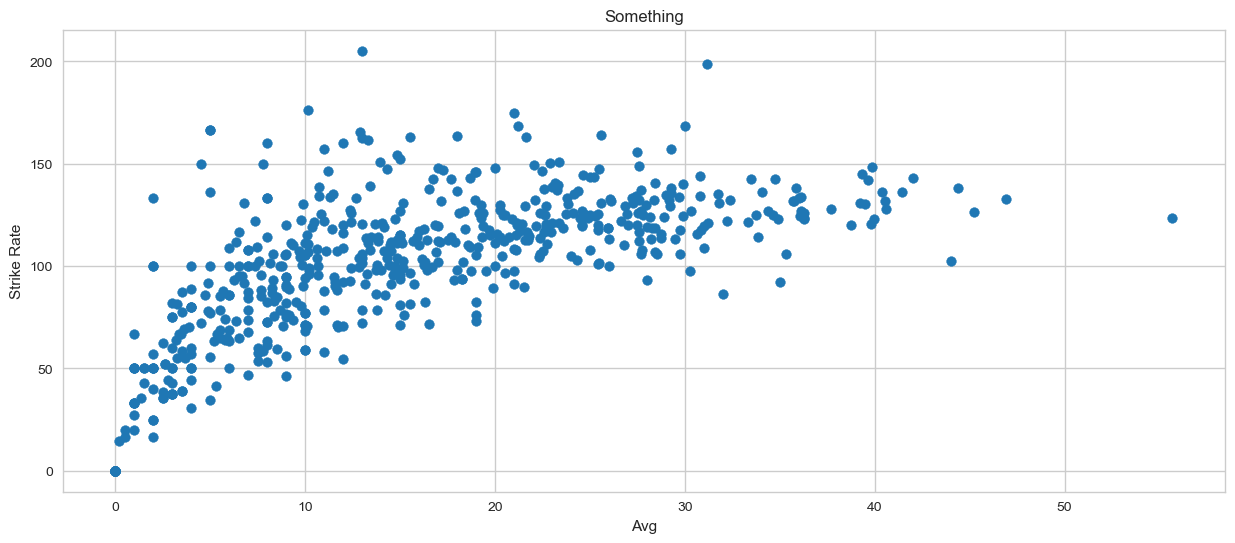

In [240]:
plt.figure(figsize=(15,6))
plt.scatter(batters['avg'],batters['strike_rate'])
plt.title('Something')
plt.xlabel('Avg')
plt.ylabel('Strike Rate' )

plt.show()

C:\Users\anish\AppData\Local\Temp\ipykernel_26464\1302960546.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


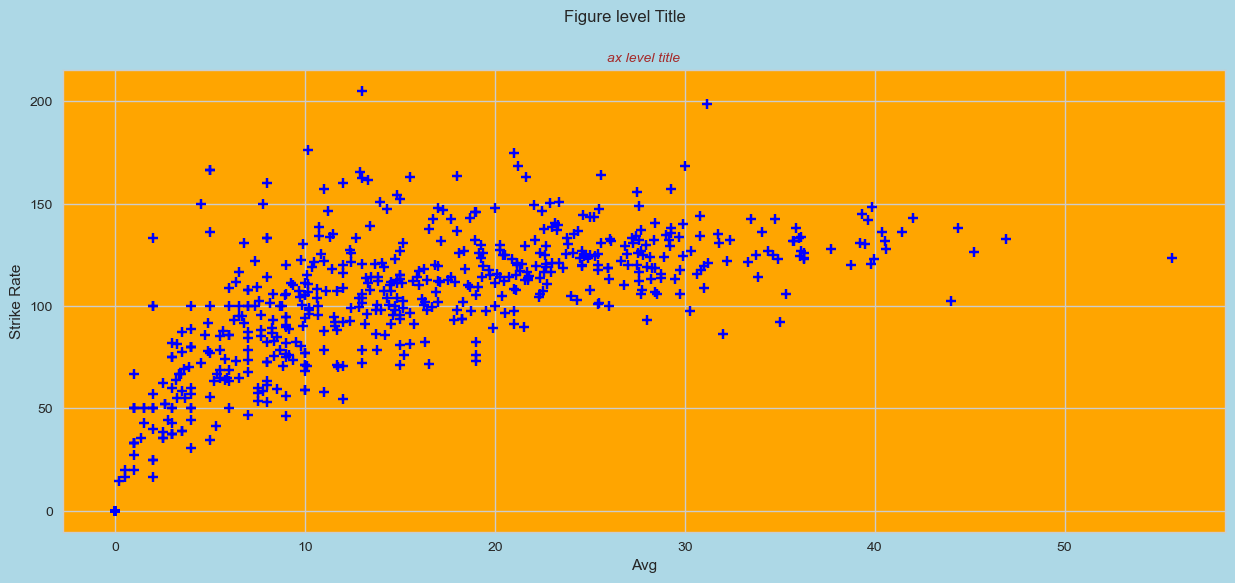

In [241]:
fig,ax = plt.subplots(figsize=(15,6))

ax.scatter(batters['avg'],batters['strike_rate'],color='blue',marker='+')
ax.set_facecolor('orange')
ax.set_title('ax level title', fontdict={'size':10,'color':'brown' , 'style':'italic'})
ax.set_xlabel('Avg')
ax.set_ylabel('Strike Rate')


fig.suptitle('Figure level Title')
fig.set_facecolor('lightblue')

fig.show()

In [242]:
# batter dataset

Text(0.5, 0, 'Avg')

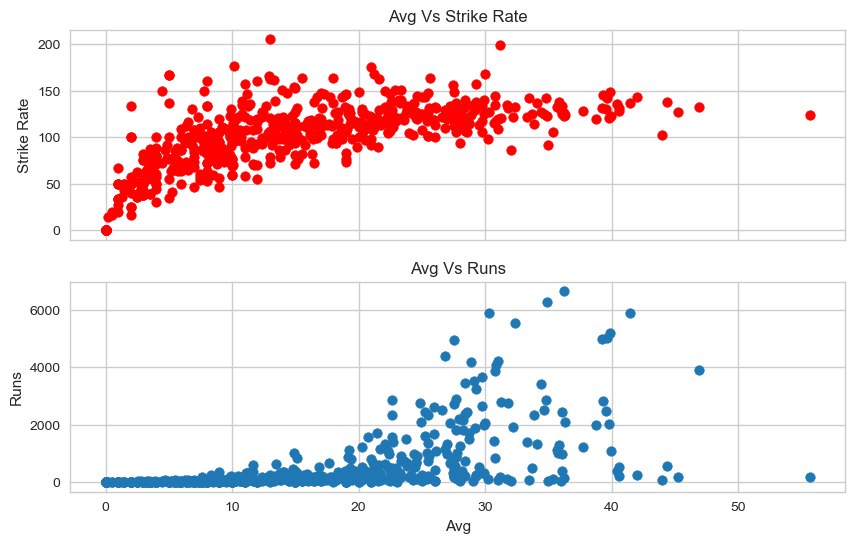

In [243]:
fig, ax = plt.subplots(nrows=2,ncols=1,sharex=True,figsize=(10,6)) # shrex : share x axis, sharey : share y axis 

ax[0].scatter(batters['avg'],batters['strike_rate'],color='red')
ax[1].scatter(batters['avg'],batters['runs'])

ax[0].set_title('Avg Vs Strike Rate')
ax[0].set_ylabel('Strike Rate')


ax[1].set_title('Avg Vs Runs')
ax[1].set_ylabel('Runs')
ax[1].set_xlabel('Avg')

(array([499.,  40.,  19.,  19.,   9.,   6.,   4.,   4.,   3.,   2.]),
 array([   0. ,  663.4, 1326.8, 1990.2, 2653.6, 3317. , 3980.4, 4643.8,
        5307.2, 5970.6, 6634. ]),
 <BarContainer object of 10 artists>)

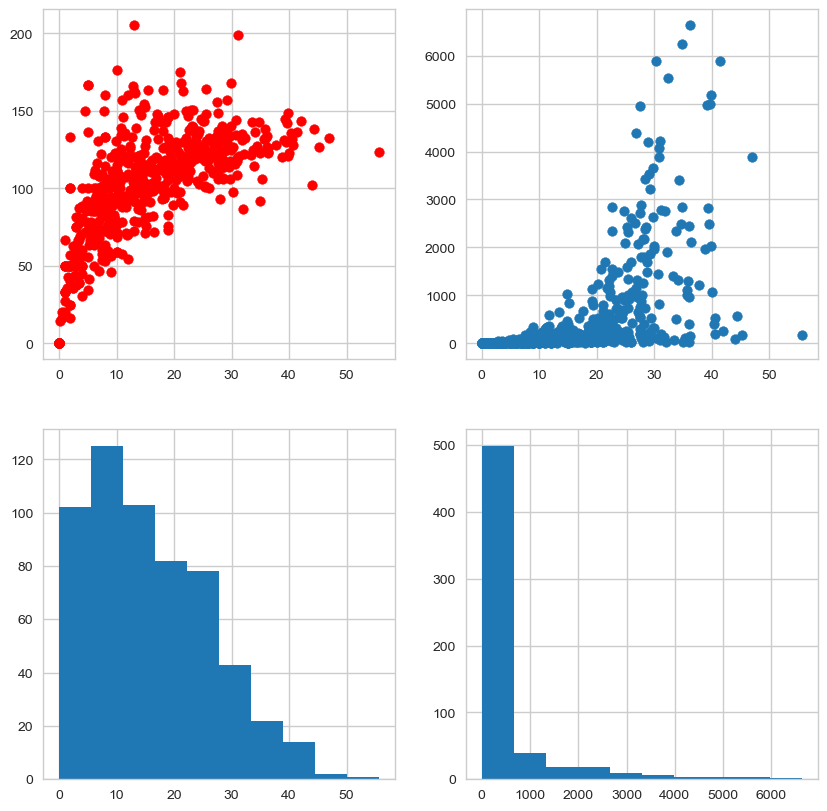

In [244]:
fig, ax = plt.subplots(nrows=2,ncols=2,figsize=(10,10))

ax[0,0].scatter(batters['avg'],batters['strike_rate'] , color='red')
ax[0,1].scatter(batters['avg'],batters['runs'])
ax[1,0].hist(batters['avg'])
ax[1,1].hist(batters['runs'])

(array([102., 125., 103.,  82.,  78.,  43.,  22.,  14.,   2.,   1.]),
 array([ 0.        ,  5.56666667, 11.13333333, 16.7       , 22.26666667,
        27.83333333, 33.4       , 38.96666667, 44.53333333, 50.1       ,
        55.66666667]),
 <BarContainer object of 10 artists>)

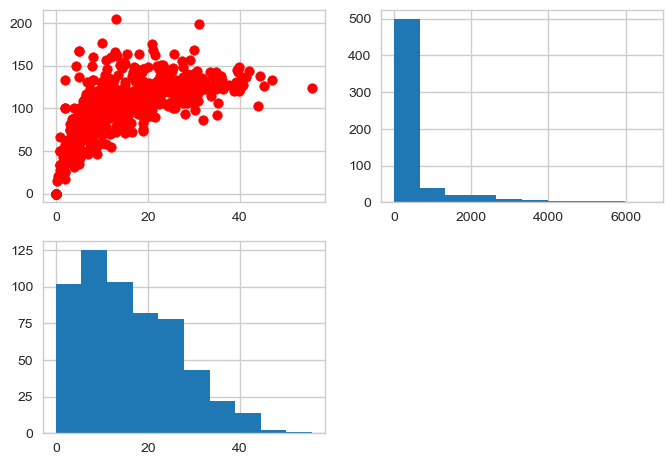

In [245]:
fig = plt.figure()

ax1 = fig.add_subplot(2,2,1)
ax1.scatter(batters['avg'],batters['strike_rate'],color='red')

ax2 = fig.add_subplot(2,2,2)
ax2.hist(batters['runs'])

ax3 = fig.add_subplot(2,2,3)
ax3.hist(batters['avg'])

<Axes: >

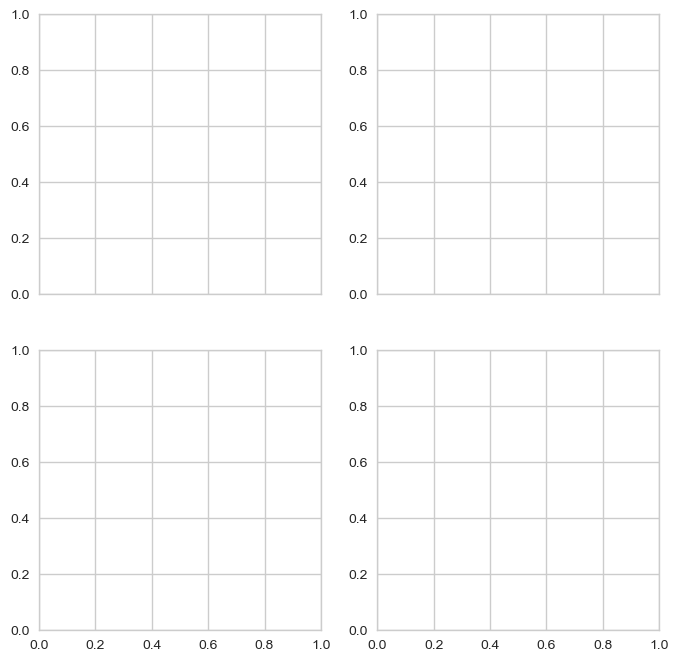

In [246]:
fig, ax = plt.subplots(nrows=2,ncols=2,sharex=True,figsize=(8,8))
ax[1,1]


## We will leran now 3D plots :
- 1. 3D Scatterplots : syntax : `ax = fig.add_subplot(111, projection='3d')`  or  `ax = fig.add_subplot(projection='3d')`  or  `ax = plt.axes(projection='3d')`
- 2. 3D Lineplots : syntax : `ax = fig.add_subplot(111, projection='3d')`  or  `ax = fig.add_subplot(projection='3d')`  or  `ax = plt.axes(projection='3d')`
- 3. 3D Surfaceplots : syntax : `ax = fig.add_subplot(111, projection='3d')`  or  `ax = fig.add_subplot(projection='3d')`  or  `ax = plt.axes(projection='3d')`
- 4. 3D Contour plots : syntax : `ax = fig.add_subplot(111, projection='3d')`  or  `ax = fig.add_subplot(projection='3d')`  or  `ax = plt.axes(projection='3d')`


### 3D Scatter Plots

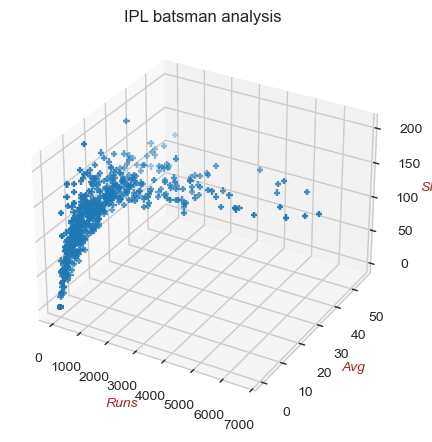

In [247]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection='3d' )

ax.scatter3D(
    batters['runs'],
    batters['avg'],
    batters['strike_rate'],
    marker='+'
)

ax.set_title('IPL batsman analysis')
ax.set_xlabel('Runs' , fontdict={'size':10,'color':'brown' , 'style':'italic'})
ax.set_ylabel('Avg' , fontdict={'size':10,'color':'brown' , 'style':'italic'})
ax.set_zlabel('SR' , fontdict={'size':10,'color':'brown' , 'style':'italic'})

plt.show()

### 3D Line Plot

Text(0.5, 0, 'Z axis')

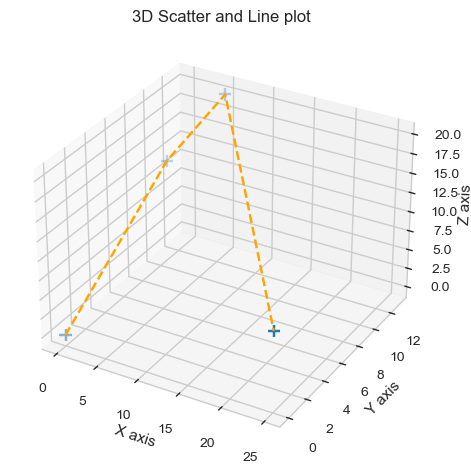

In [248]:
x = [0,1,5,25]
y = [0,10,13,0]
z = [0,13,20,9]

fig = plt.figure()

ax = fig.add_subplot(projection='3d')

ax.scatter3D(x,y,z,s=[80,80,80,80],marker="+")
ax.plot3D(x,y,z,color='orange',linestyle='dashed')
ax.set_title('3D Scatter and Line plot')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')

### 3D Surface Plots

[MeshGrid Tutorial 🔗](https://www.youtube.com/watch?v=7K_a1mmraHU)
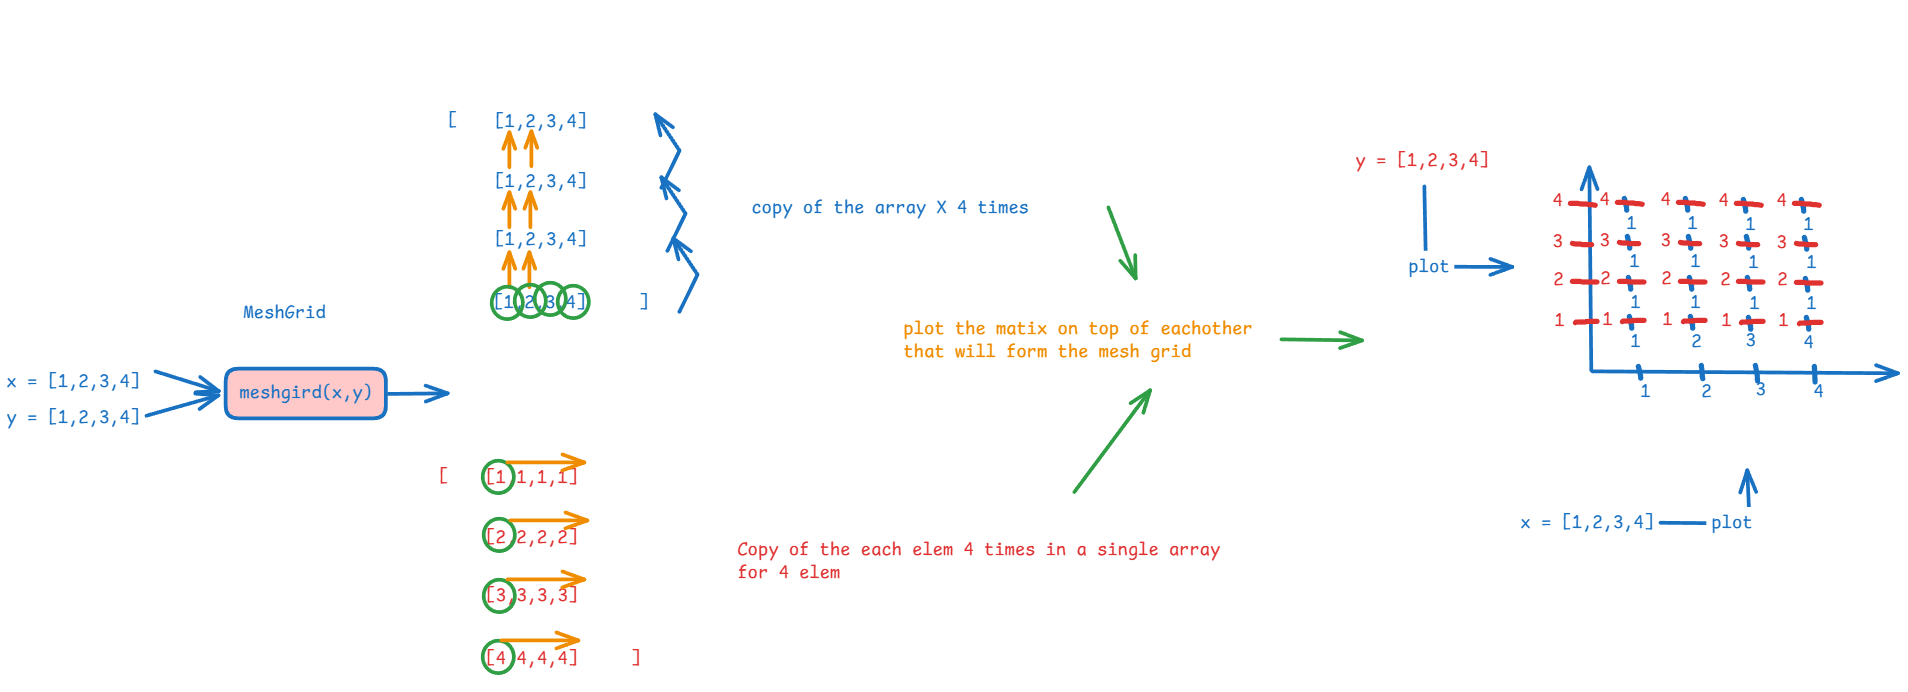

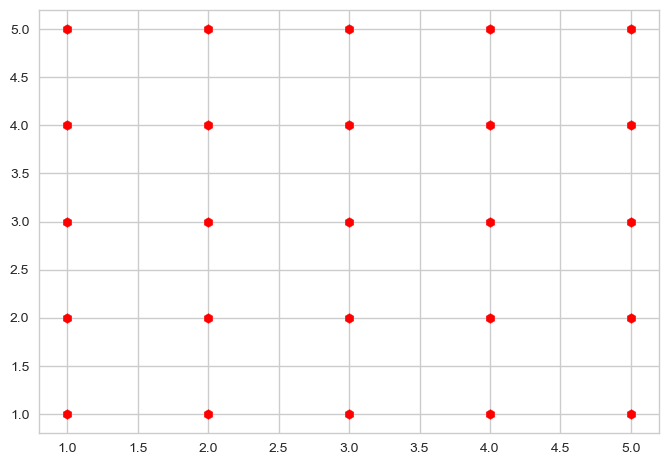

In [249]:
x = np.array([1,2,3,4,5])
y = np.array([1,2,3,4, 5])
xx , yy = np.meshgrid(x,y)

plt.scatter(xx,yy , marker='h' , color='red')

In [250]:
x = np.linspace(-10,10,100)
y = np.linspace(-10,10,100)

In [251]:
xx, yy = np.meshgrid(x,y)

In [252]:
z = xx**2 + yy**2
z.shape

(100, 100)

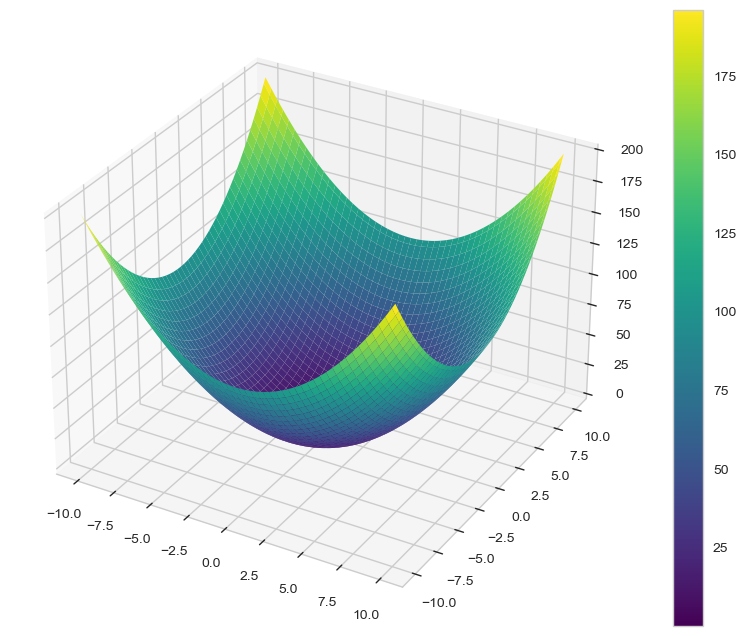

In [261]:
z = xx**2 + yy**2
fig = plt.figure(figsize=(12,8))

ax = plt.subplot(projection='3d')

p = ax.plot_surface(xx,yy,z,cmap='viridis')
fig.colorbar(p)

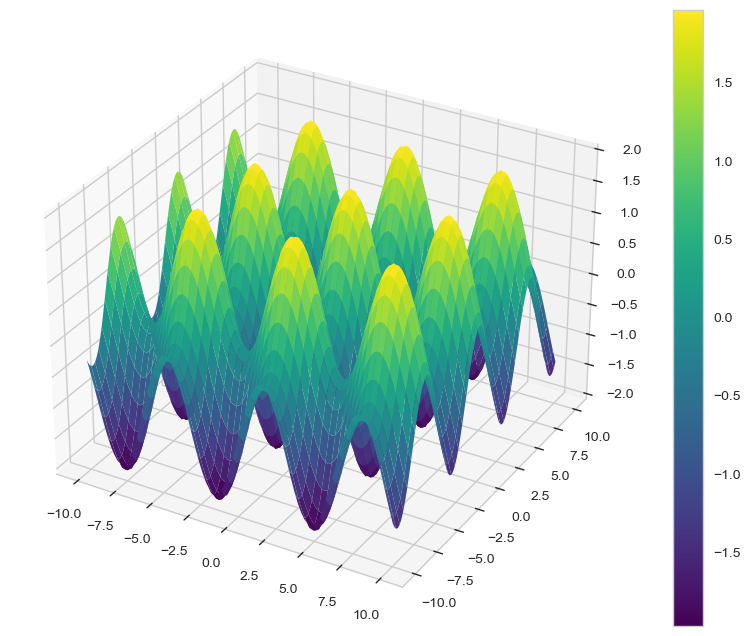

In [266]:
z = np.sin(xx) + np.cos(yy)

fig = plt.figure(figsize=(12,8))

ax = plt.subplot(projection='3d')

p = ax.plot_surface(xx,yy,z,cmap='viridis')
fig.colorbar(p)

C:\Users\anish\AppData\Local\Temp\ipykernel_26464\684431574.py:1: RuntimeWarning: invalid value encountered in log
  z = np.sin(xx) + np.log(xx)


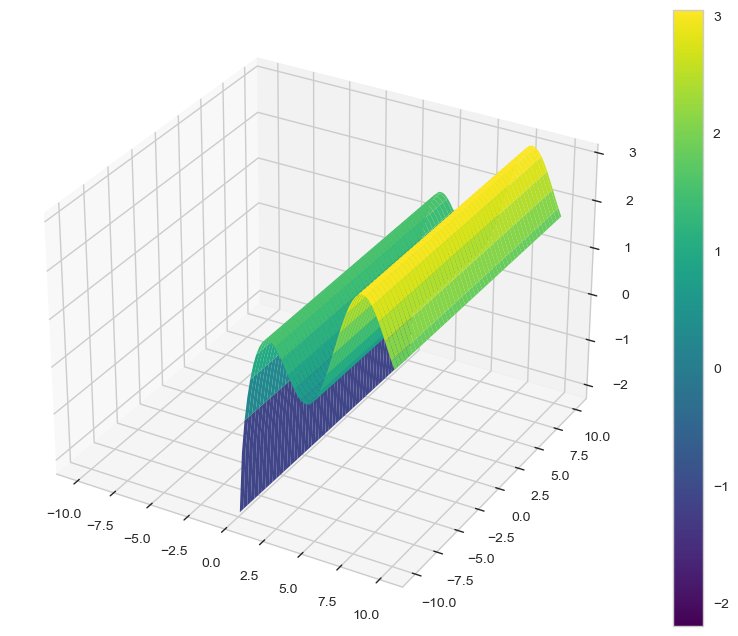

In [255]:
z = np.sin(xx) + np.log(xx)

fig = plt.figure(figsize=(12,8))

ax = plt.subplot(projection='3d')

p = ax.plot_surface(xx,yy,z,cmap='viridis')
fig.colorbar(p)

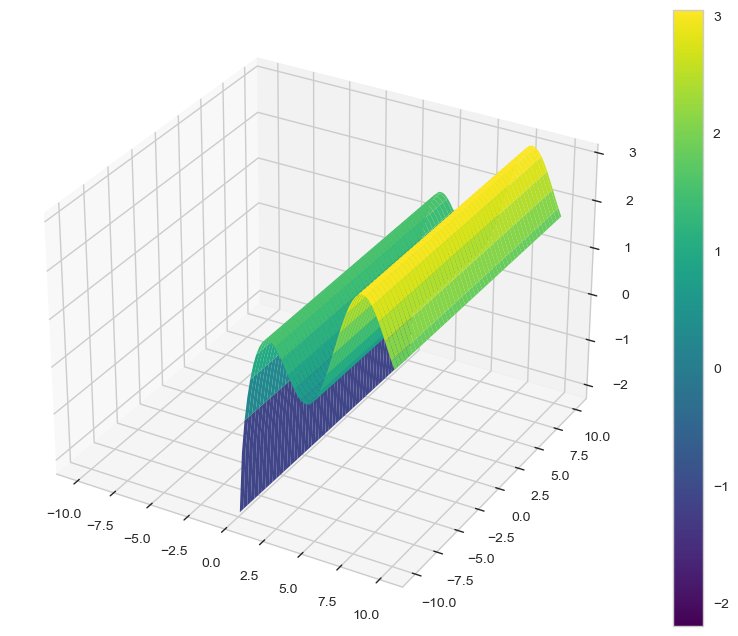

In [256]:
fig = plt.figure(figsize=(12,8))

ax = plt.subplot(projection='3d')

p = ax.plot_surface(xx,yy,z,cmap='viridis')
fig.colorbar(p)

### Contour Plots

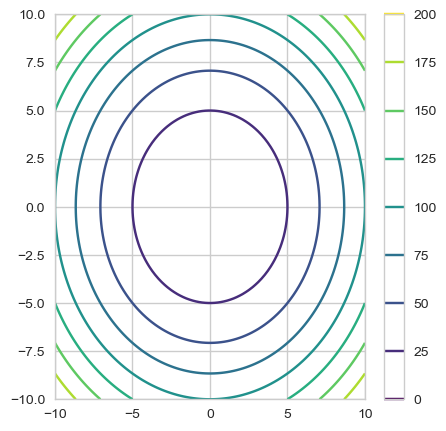

In [265]:
fig = plt.figure(figsize=(5,5))

ax = plt.subplot()

p = ax.contour(xx,yy,z,cmap='viridis')
fig.colorbar(p)

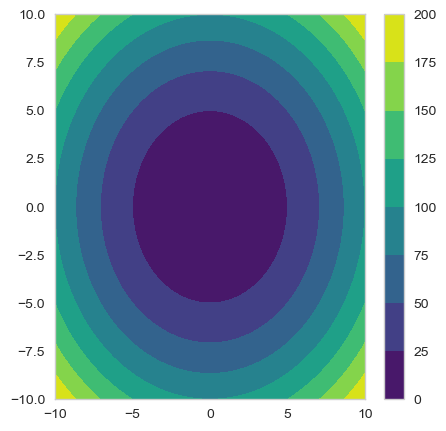

In [264]:
fig = plt.figure(figsize=(5,5))

ax = plt.subplot()

p = ax.contourf(xx,yy,z,cmap='viridis')
fig.colorbar(p)

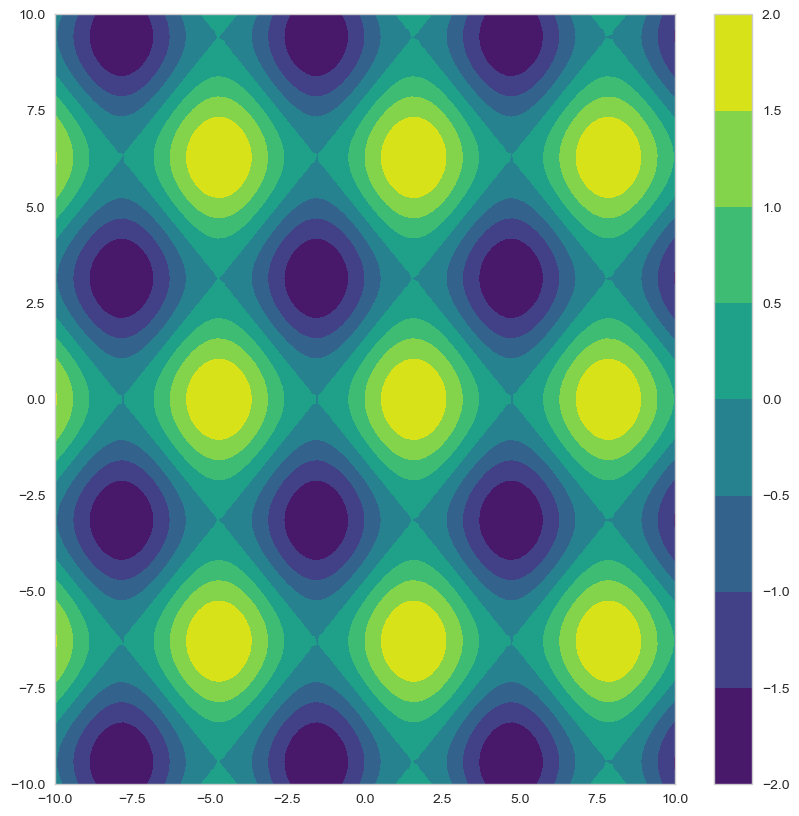

In [268]:
z = np.sin(xx) + np.cos(yy)

fig = plt.figure(figsize=(10,10))

ax = plt.subplot()

p = ax.contourf(xx,yy,z,cmap='viridis')
fig.colorbar(p)

### Heatmap

In [269]:
delivery = pd.read_csv('../data/IPL_Ball_by_Ball_2008_2022.csv')
delivery.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals


In [ ]:
# number of balls in which 6 was scored and the ball number is 1,2,3,4,5,6 olny not the wide balls or no balls like ball no. 7 , 8 , 9 , ... etc . 
temp_df = delivery[(delivery['ballnumber'].isin([1,2,3,4,5,6])) & (delivery['batsman_run']==6)] 

In [272]:
grid = temp_df.pivot_table(index='overs',columns='ballnumber',values='batsman_run',aggfunc='count')
grid.head()

ballnumber,1,2,3,4,5,6
overs,,,,,,
0,9,17,31,39,33,27
1,31,40,49,56,58,54
2,75,62,70,72,58,76
3,60,74,74,103,74,71
4,71,76,112,80,81,72


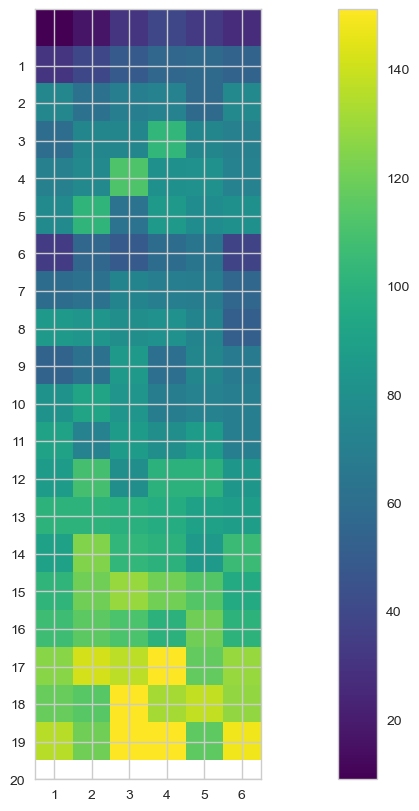

In [279]:
plt.figure(figsize=(20,10))
plt.imshow(grid , cmap='viridis')
plt.yticks(list(range(1,21)))
plt.xticks(np.arange(0,6), list(range(1,7)))
plt.colorbar()

## Pandas Plot()

<Axes: >

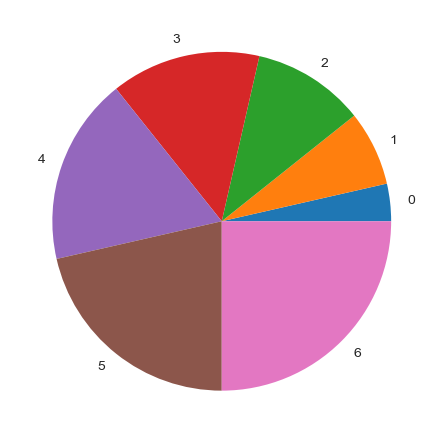

In [280]:
# on a series

s = pd.Series([1,2,3,4,5,6,7])
s.plot(kind='pie')

In [281]:
# can be used on a dataframe as well

In [282]:
import seaborn as sns
tips = sns.load_dataset('tips')

In [283]:
tips['size'] = tips['size'] * 100

In [284]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,200
1,10.34,1.66,Male,No,Sun,Dinner,300
2,21.01,3.50,Male,No,Sun,Dinner,300
3,23.68,3.31,Male,No,Sun,Dinner,200
4,24.59,3.61,Female,No,Sun,Dinner,400


<Axes: title={'center': 'Cost Analysis'}, xlabel='total_bill', ylabel='tip'>

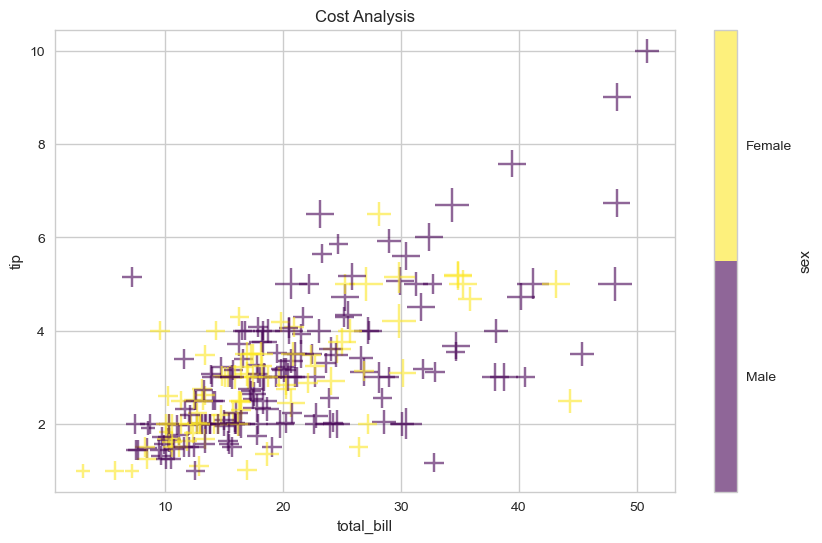

In [288]:
# Scatter plot -> labels -> markers -> figsize -> color -> cmap
tips.plot(kind='scatter',x='total_bill',y='tip',title='Cost Analysis',marker='+',figsize=(10,6),s='size',c='sex',cmap='viridis',alpha=0.6)

In [289]:
# 2d plot
# dataset = 'https://raw.githubusercontent.com/m-mehdi/pandas_tutorials/main/weekly_stocks.csv'

stocks = pd.read_csv('https://raw.githubusercontent.com/m-mehdi/pandas_tutorials/main/weekly_stocks.csv')
stocks.head()

,Date,MSFT,FB,AAPL
0,2021-05-24,249.679993,328.730011,124.610001
1,2021-05-31,250.789993,330.350006,125.889999
2,2021-06-07,257.890015,331.260010,127.349998
3,2021-06-14,259.429993,329.660004,130.460007
4,2021-06-21,265.019989,341.369995,133.110001


<Axes: >

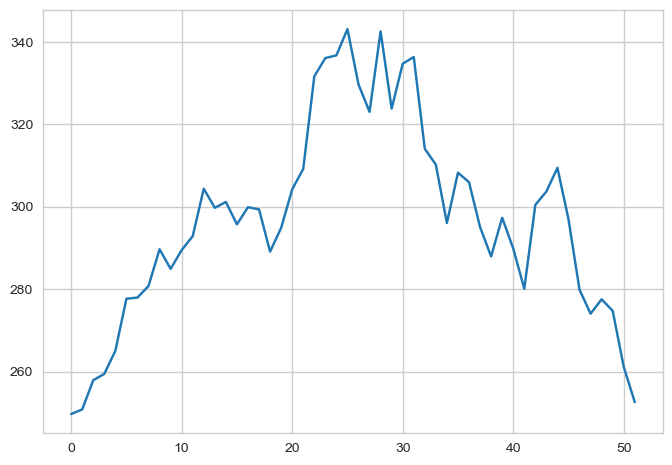

In [290]:
# line plot
stocks['MSFT'].plot(kind='line')

<Axes: xlabel='Date'>

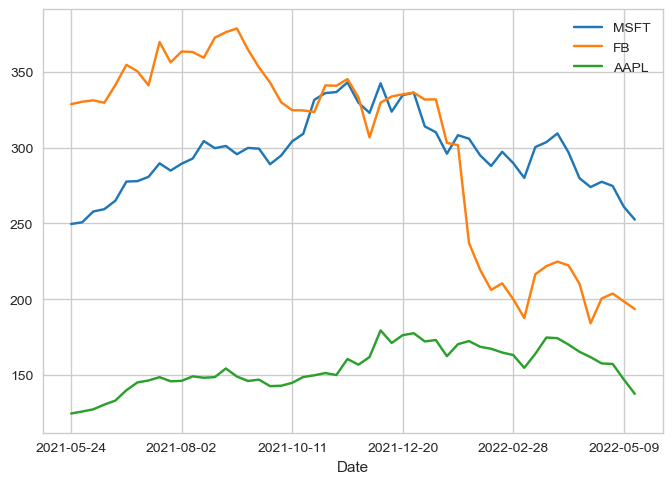

In [291]:
stocks.plot(kind='line',x='Date')

<Axes: xlabel='Date'>

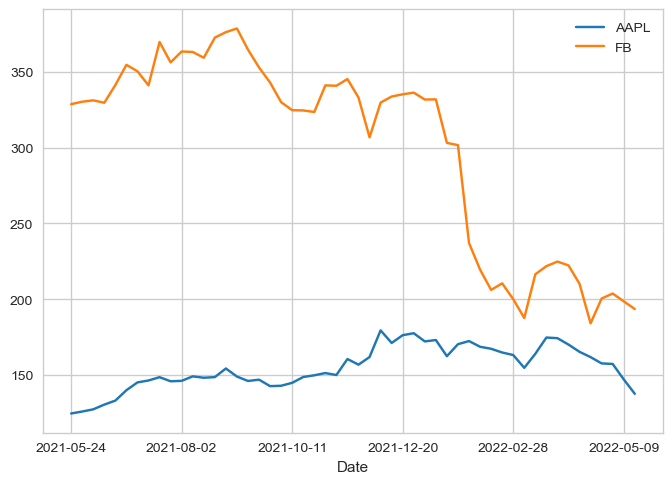

In [292]:
stocks[['Date','AAPL','FB']].plot(kind='line',x='Date')

In [294]:
# bar chart -> single -> horizontal -> multiple
# using tips
temp = pd.read_csv('../data/batsman_season_record.csv')
temp.head()

,batsman,2015,2016,2017
0,AB de Villiers,513,687,216
1,DA Warner,562,848,641
2,MS Dhoni,372,284,290
3,RG Sharma,482,489,333
4,V Kohli,505,973,308


C:\Users\anish\AppData\Local\Temp\ipykernel_26464\403480899.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tips.groupby('sex')['total_bill'].mean().plot(kind='bar' , xlabel='Sex',ylabel='Average Bill',title='Average Bill by Sex')


<Axes: title={'center': 'Average Bill by Sex'}, xlabel='Sex', ylabel='Average Bill'>

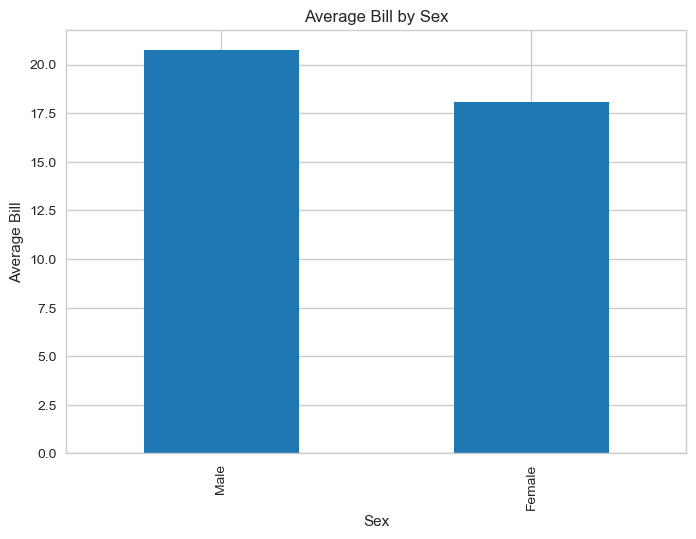

In [299]:
tips.groupby('sex')['total_bill'].mean().plot(kind='bar' , xlabel='Sex',ylabel='Average Bill',title='Average Bill by Sex')

<Axes: title={'center': 'Batsman Runs in 2015'}, xlabel='Batsman', ylabel='Runs'>

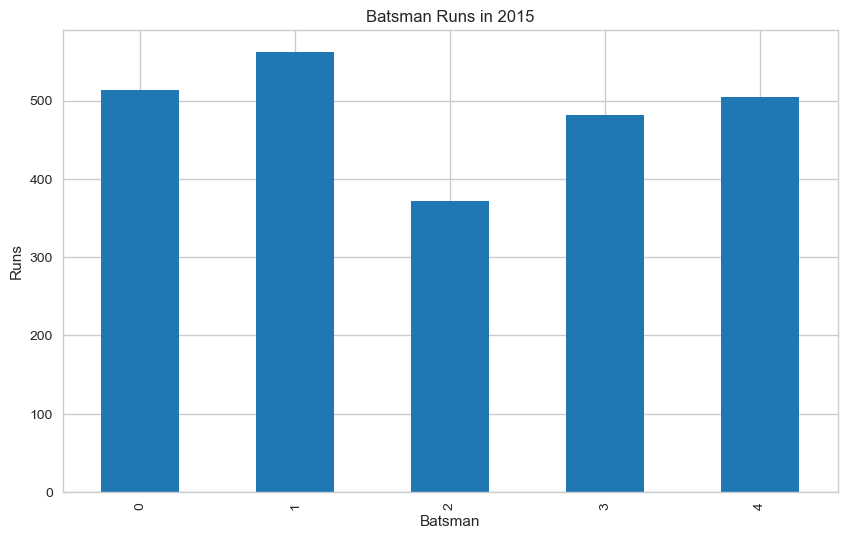

In [300]:
temp['2015'].plot(kind='bar' , xlabel='Batsman',ylabel='Runs',title='Batsman Runs in 2015',figsize=(10,6))

<Axes: title={'center': 'Batsman Runs in 2015'}, xlabel='Batsman', ylabel='Runs'>

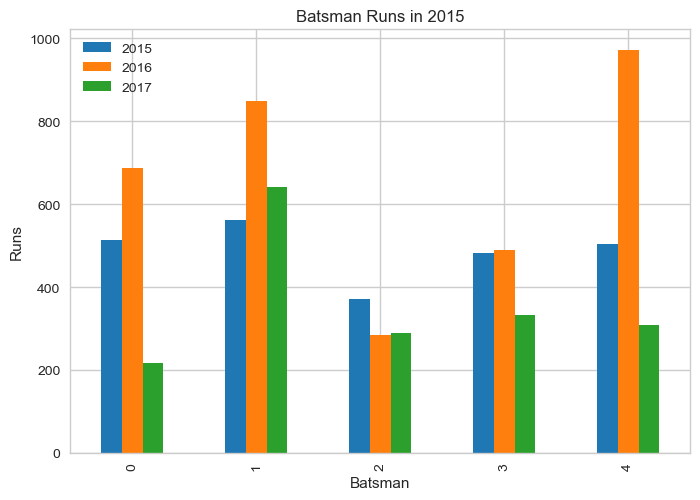

In [301]:
temp.plot(kind='bar' , xlabel='Batsman',ylabel='Runs',title='Batsman Runs in 2015' )

<Axes: >

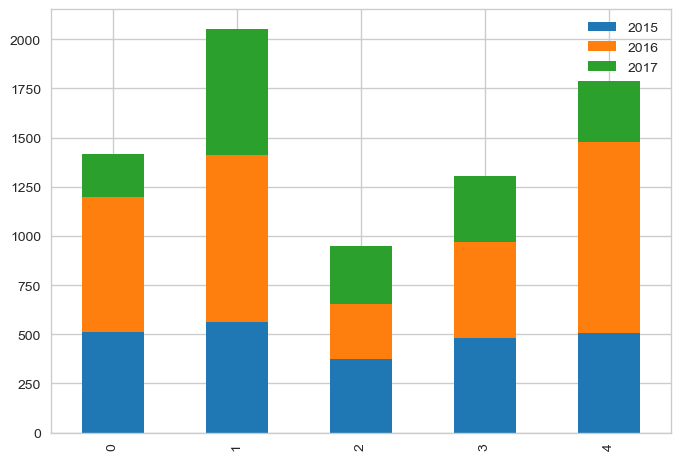

In [302]:
# stacked bar chart
temp.plot(kind='bar',stacked=True)

<Axes: ylabel='Frequency'>

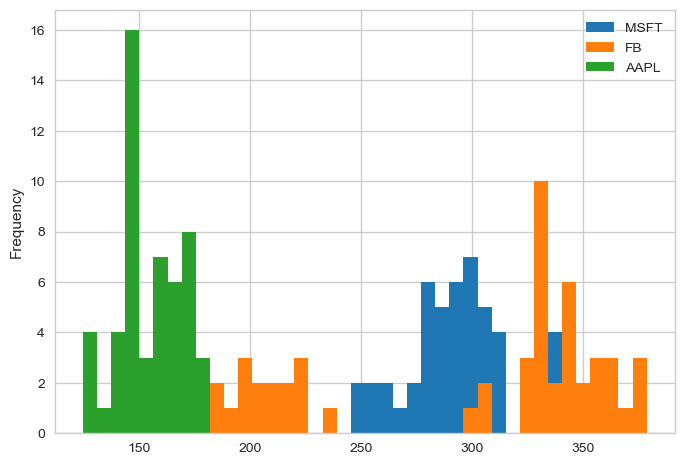

In [303]:
# histogram
# using stocks

stocks.plot(kind='hist',bins=40)

In [304]:
# pie -> single and multiple
df = pd.DataFrame(
    {
        'batsman':['Dhawan','Rohit','Kohli','SKY','Pandya','Pant'],
        'match1':[120,90,35,45,12,10],
        'match2':[0,1,123,130,34,45],
        'match3':[50,24,145,45,10,90]
    }
)

df.head()

,batsman,match1,match2,match3
0,Dhawan,120,0,50
1,Rohit,90,1,24
2,Kohli,35,123,145
3,SKY,45,130,45
4,Pandya,12,34,10


<Axes: ylabel='match1'>

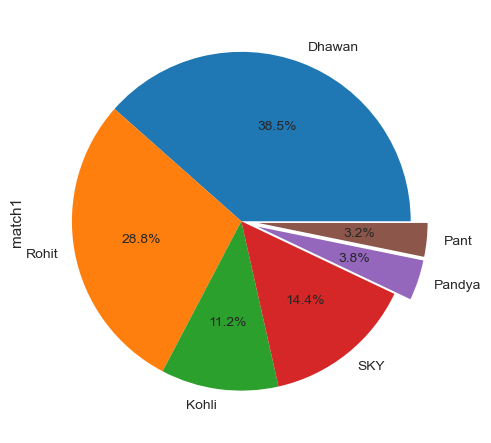

In [311]:
df['match1'].plot(kind='pie',labels=df['batsman'].values,autopct='%0.1f%%' , explode=[0,0,0,0,0.1,0.1],)

In [324]:
df.columns[1:].tolist()

['match1', 'match2', 'match3']

array([<Axes: title={'center': 'match1'}, ylabel='match1'>,
       <Axes: title={'center': 'match2'}, ylabel='match2'>,
       <Axes: title={'center': 'match3'}, ylabel='match3'>], dtype=object)

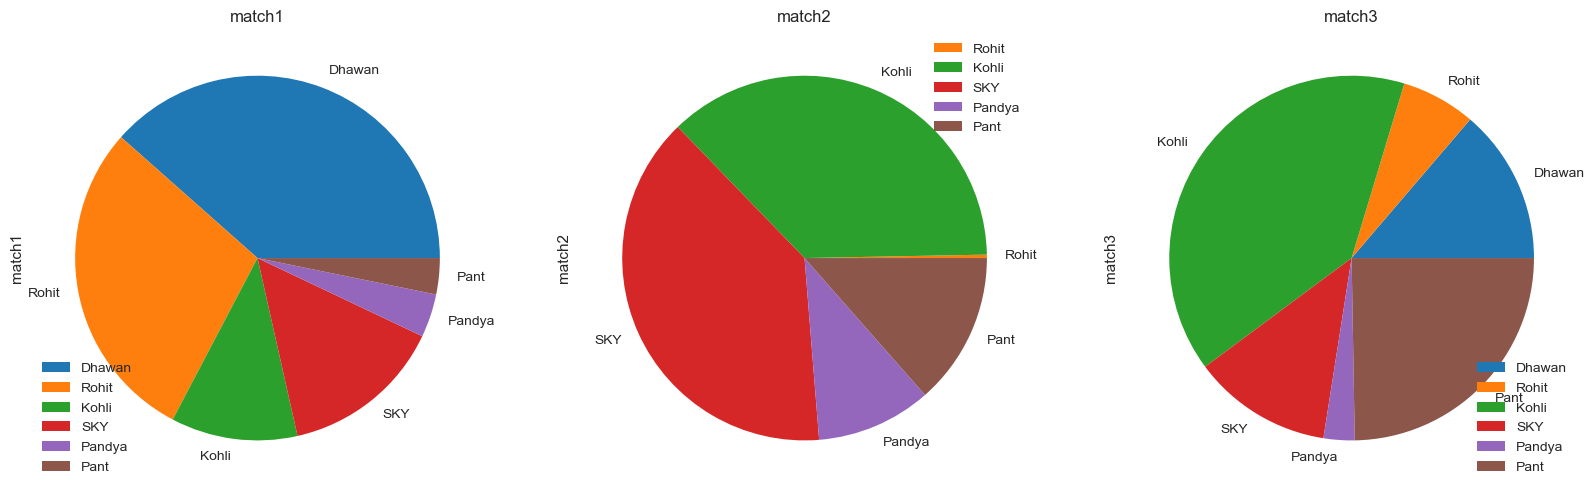

In [329]:
# multiple pie charts

df[['match1','match2','match3']].plot(kind='pie',labels=df['batsman'].values,subplots=True,figsize=(20,10),title = df.columns[1:].tolist())

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

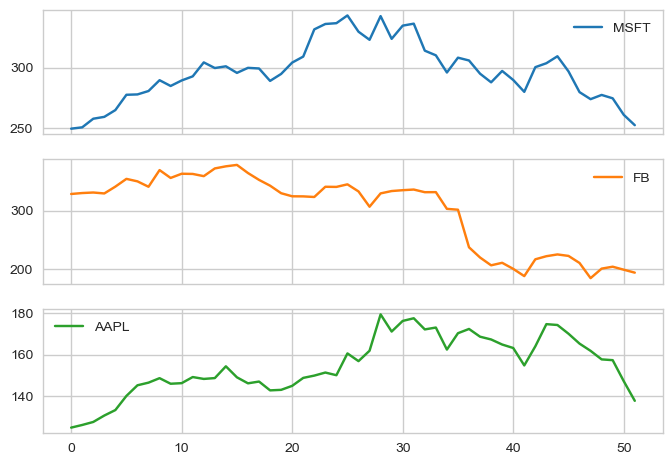

In [330]:
# multiple separate graphs together
# using stocks

stocks.plot(kind='line',subplots=True)

In [ ]:
# on multiindex dataframes
# using tips

In [332]:
tips.pivot_table(index=['day','time'],columns=['sex','smoker'],values='total_bill',aggfunc='mean')

C:\Users\anish\AppData\Local\Temp\ipykernel_26464\2427590639.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tips.pivot_table(index=['day','time'],columns=['sex','smoker'],values='total_bill',aggfunc='mean')


sex               Male                Female           
smoker             Yes         No        Yes         No
day  time                                              
Thur Lunch   19.171000  18.486500  19.218571  15.899167
     Dinner        NaN        NaN        NaN  18.780000
Fri  Lunch   11.386667        NaN  13.260000  15.980000
     Dinner  25.892000  17.475000  12.200000  22.750000
Sat  Dinner  21.837778  19.929063  20.266667  19.003846
Sun  Dinner  26.141333  20.403256  16.540000  20.824286

C:\Users\anish\AppData\Local\Temp\ipykernel_26464\3307320567.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tips.pivot_table(index=['day','time'],columns=['sex','smoker'],values='total_bill',aggfunc='mean').plot(kind='bar')


<Axes: xlabel='day,time'>

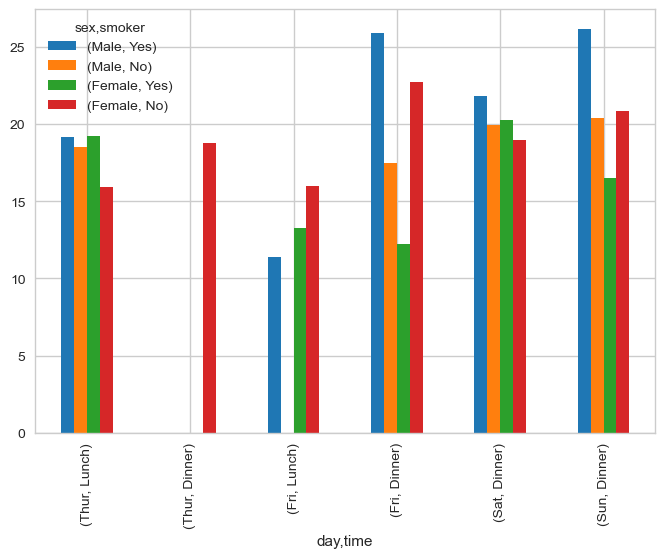

In [333]:
tips.pivot_table(index=['day','time'],columns=['sex','smoker'],values='total_bill',aggfunc='mean').plot(kind='bar')

C:\Users\anish\AppData\Local\Temp\ipykernel_26464\2410627224.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tips.pivot_table(index=['day','time'],columns=['sex','smoker'],values='total_bill',aggfunc='mean').plot(kind='pie',subplots=True,figsize=(20,10))


array([<Axes: ylabel='(Male, Yes)'>, <Axes: ylabel='(Male, No)'>,
       <Axes: ylabel='(Female, Yes)'>, <Axes: ylabel='(Female, No)'>],
      dtype=object)

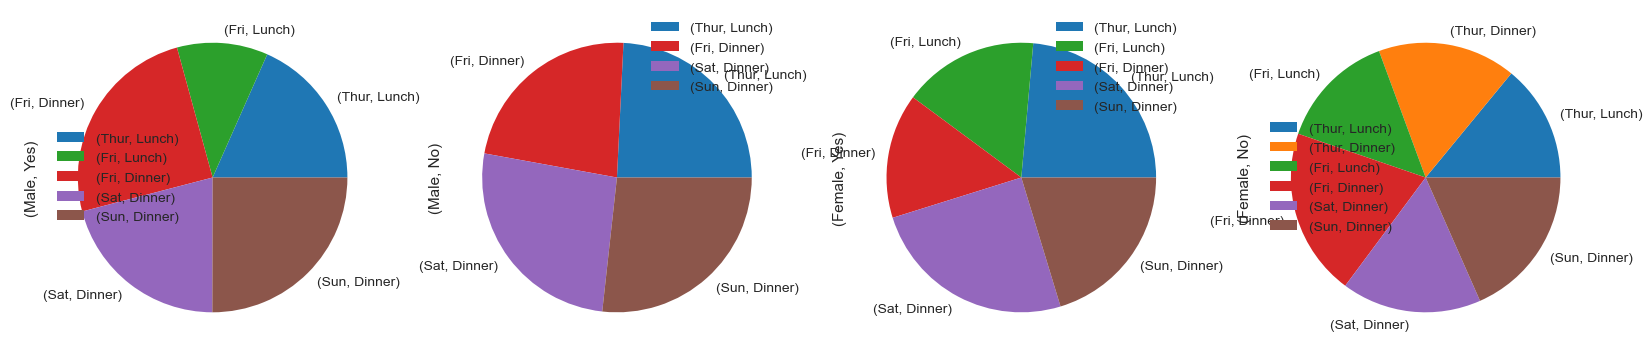

In [331]:
tips.pivot_table(index=['day','time'],columns=['sex','smoker'],values='total_bill',aggfunc='mean').plot(kind='pie',subplots=True,figsize=(20,10))

In [ ]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,200
1,10.34,1.66,Male,No,Sun,Dinner,300
2,21.01,3.50,Male,No,Sun,Dinner,300
3,23.68,3.31,Male,No,Sun,Dinner,200
4,24.59,3.61,Female,No,Sun,Dinner,400
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,300
240,27.18,2.00,Female,Yes,Sat,Dinner,200
241,22.67,2.00,Male,Yes,Sat,Dinner,200
242,17.82,1.75,Male,No,Sat,Dinner,200


In [ ]:
stocks.plot(kind='scatter3D')

ValueError: ignored